In [24]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

# Visual style setup
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Connect to SQLite Database via SQLAlchemy
DB_PATH = "sqlite:///../data/processed/enrollment.db"
engine = create_engine(DB_PATH)

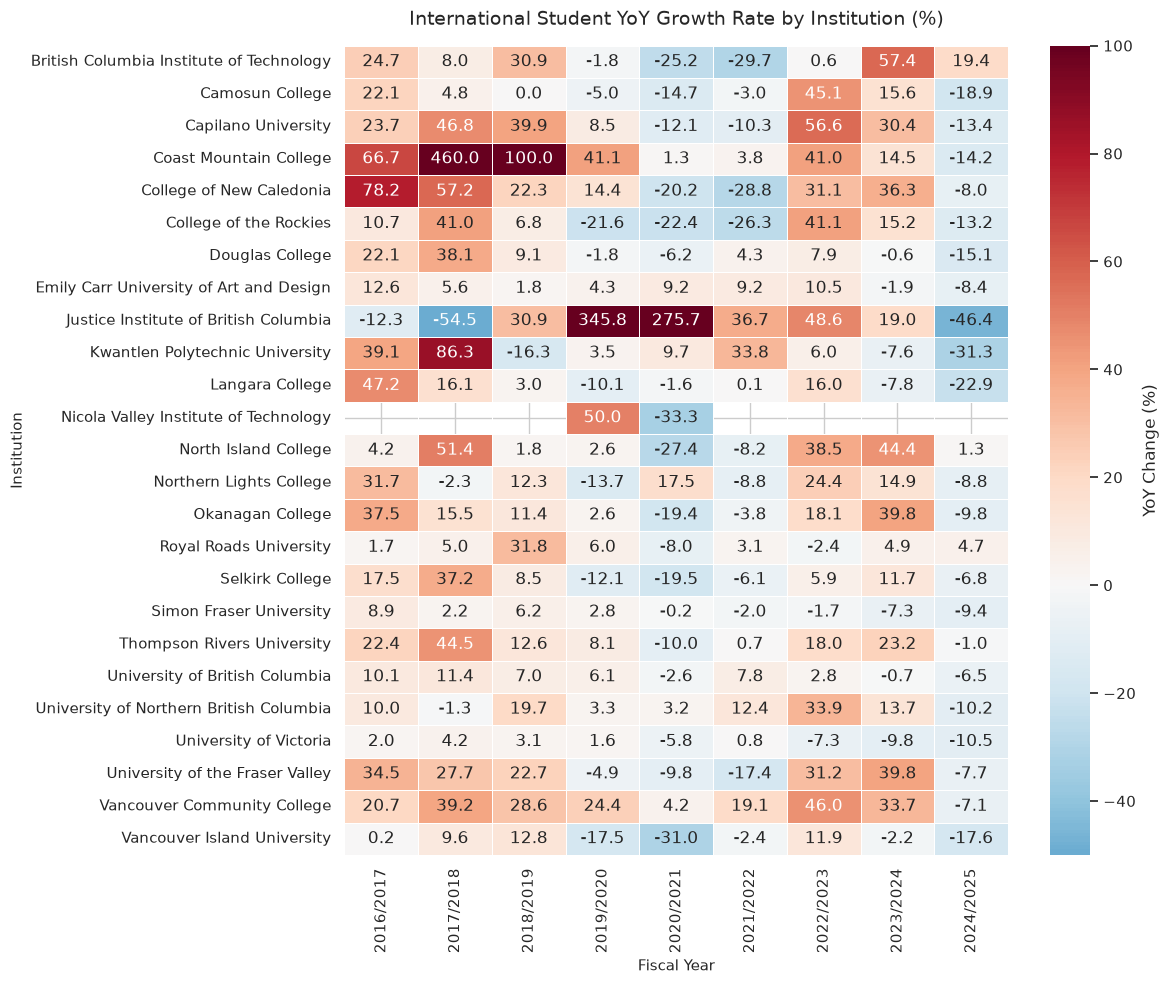

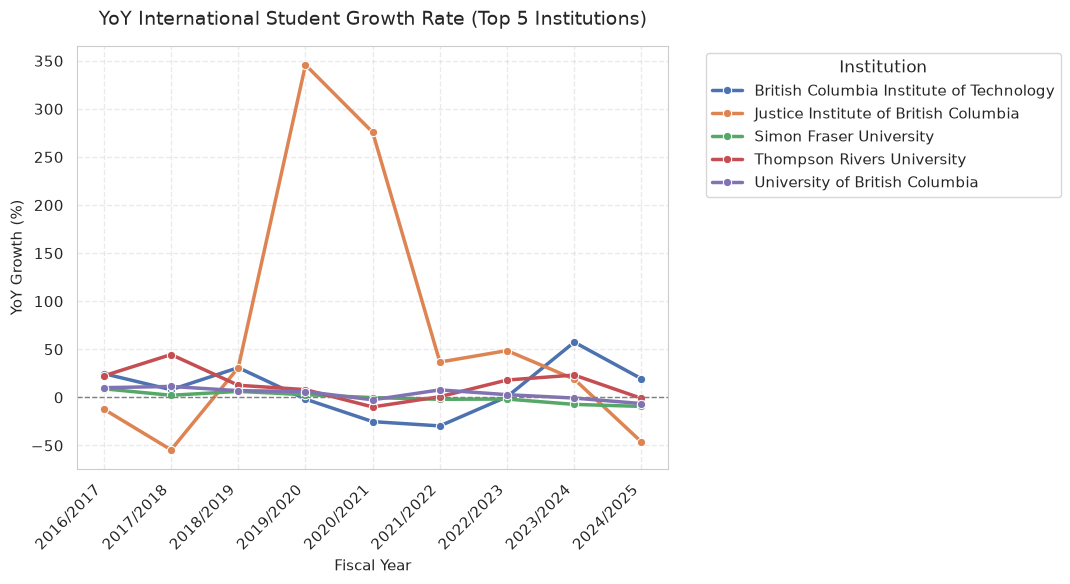

In [ ]:
# ==============================================================================
# Query 1: Year-over-Year (YoY) % Change in International Headcount
# ==============================================================================
query_yoy = """
WITH international_by_year AS (
    SELECT 
        i.institution_name,
        f.fiscal_year,
        SUM(f.headcount) AS intl_headcount
    FROM fact_student_headcount f
    JOIN dim_institution i ON f.institution_id = i.institution_id
    WHERE f.student_type = 'International'
    GROUP BY i.institution_name, f.fiscal_year
)
SELECT 
    institution_name,
    fiscal_year,
    intl_headcount,
    LAG(intl_headcount) OVER (
        PARTITION BY institution_name 
        ORDER BY fiscal_year
    ) AS prev_year_headcount,
    ROUND(
        (CAST(intl_headcount AS FLOAT) - LAG(intl_headcount) OVER (
            PARTITION BY institution_name ORDER BY fiscal_year
        )) / NULLIF(LAG(intl_headcount) OVER (
            PARTITION BY institution_name ORDER BY fiscal_year
        ), 0) * 100, 2
    ) AS yoy_pct_change
FROM international_by_year
ORDER BY institution_name, fiscal_year;
"""

df_yoy = pd.read_sql(query_yoy, engine)

# Pivot data for heatmap (Institutions x Fiscal Years)
df_pivot = df_yoy.pivot(
    index='institution_name', 
    columns='fiscal_year', 
    values='yoy_pct_change'
)

# Pivot data for heatmap (Institutions x Fiscal Years)
df_pivot = df_yoy.pivot(
    index='institution_name', 
    columns='fiscal_year', 
    values='yoy_pct_change'
)

# Drop initial fiscal year column (contains NaN due to LAG)
df_pivot = df_pivot.dropna(how='all', axis=1)

# Plot Heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",        # Red = Negative, Blue = Positive
    center=0,             # Neutral white at 0%
    vmin=-50,             # Sets red intensity floor for negative values
    vmax=100,             # Sets blue saturation ceiling so lower positive growth is visible
    cbar_kws={'label': 'YoY Change (%)'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('International Student YoY Growth Rate by Institution (%)', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('Institution', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/01a_intl_yoy_growth_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# Identify top 5 institutions by latest total international headcount
top_5_inst = (
    df_yoy[df_yoy['fiscal_year'] == df_yoy['fiscal_year'].max()]
    .nlargest(5, 'intl_headcount')['institution_name']
    .tolist()
)

df_top5 = df_yoy[df_yoy['institution_name'].isin(top_5_inst)].dropna(subset=['yoy_pct_change'])

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=df_top5, 
    x='fiscal_year', 
    y='yoy_pct_change', 
    hue='institution_name', 
    marker='o', 
    linewidth=2.5
)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('YoY International Student Growth Rate (Top 5 Institutions)', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('YoY Growth (%)', fontsize=11)

# Rotate x-axis labels to prevent text overlap
plt.xticks(rotation=45, ha='right')

plt.legend(title='Institution', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/processed/01b_intl_yoy_growth_top5.png', dpi=300, bbox_inches='tight')
plt.show()

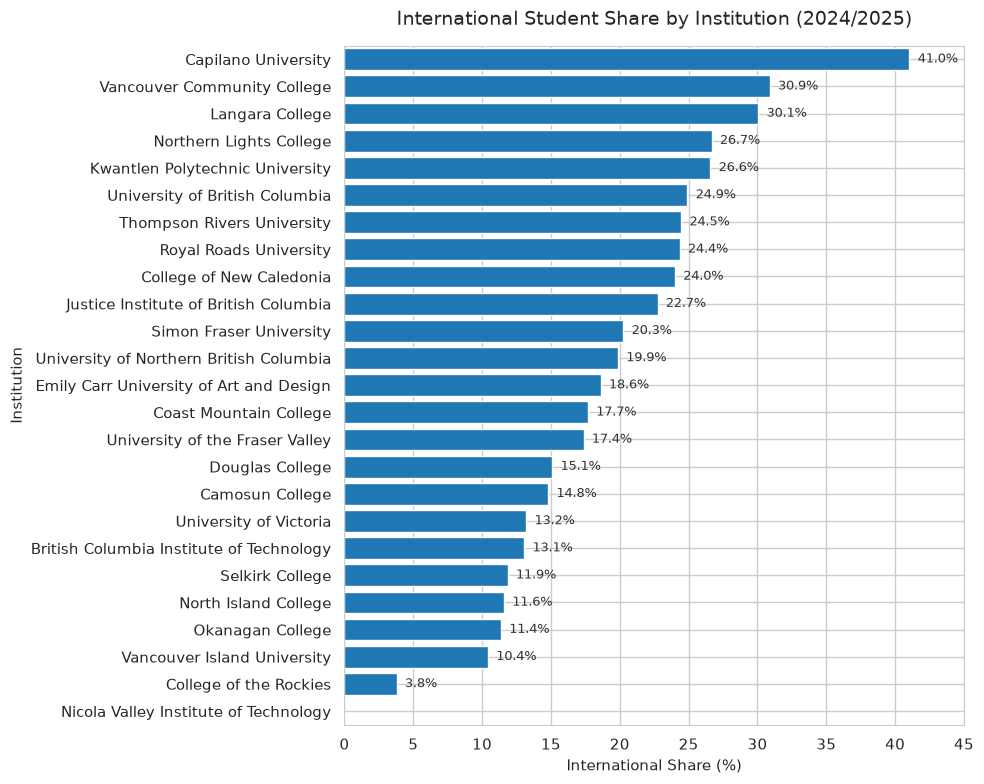

In [ ]:
# ==============================================================================
# Query 2: Rank Institutions by International Student Share (2024/2025)
# ==============================================================================
query_share = """
WITH student_breakdown AS (
    SELECT 
        i.institution_name,
        SUM(CASE WHEN f.student_type = 'International' THEN f.headcount ELSE 0 END) AS intl_headcount,
        SUM(f.headcount) AS total_headcount
    FROM fact_student_headcount f
    JOIN dim_institution i ON f.institution_id = i.institution_id
    WHERE f.fiscal_year = '2024/2025'
    GROUP BY i.institution_name
)
SELECT 
    institution_name,
    intl_headcount,
    total_headcount,
    ROUND(CAST(intl_headcount AS FLOAT) / NULLIF(total_headcount, 0) * 100, 2) AS intl_share_pct,
    RANK() OVER (
        ORDER BY CAST(intl_headcount AS FLOAT) / NULLIF(total_headcount, 0) DESC
    ) AS intl_share_rank
FROM student_breakdown
ORDER BY intl_share_rank;
"""

df_share = pd.read_sql(query_share, engine)

# Visualization
plt.figure(figsize=(10, 8))

bars = plt.barh(df_share['institution_name'], df_share['intl_share_pct'], color='#1f77b4')
plt.gca().invert_yaxis()

plt.title('International Student Share by Institution (2024/2025)', fontsize=14, pad=15)
plt.xlabel('International Share (%)', fontsize=11)
plt.ylabel('Institution', fontsize=11)

# Set tight limits on the y-axis to eliminate top and bottom whitespace
plt.ylim(len(df_share) - 0.5, -0.5)

# Set x-axis limit for label clearance
plt.xlim(0, 45)

# Add value labels
for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 0.6, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 va='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.savefig('../data/processed/02_intl_share_2024_2025.png', dpi=300, bbox_inches='tight')
plt.show()

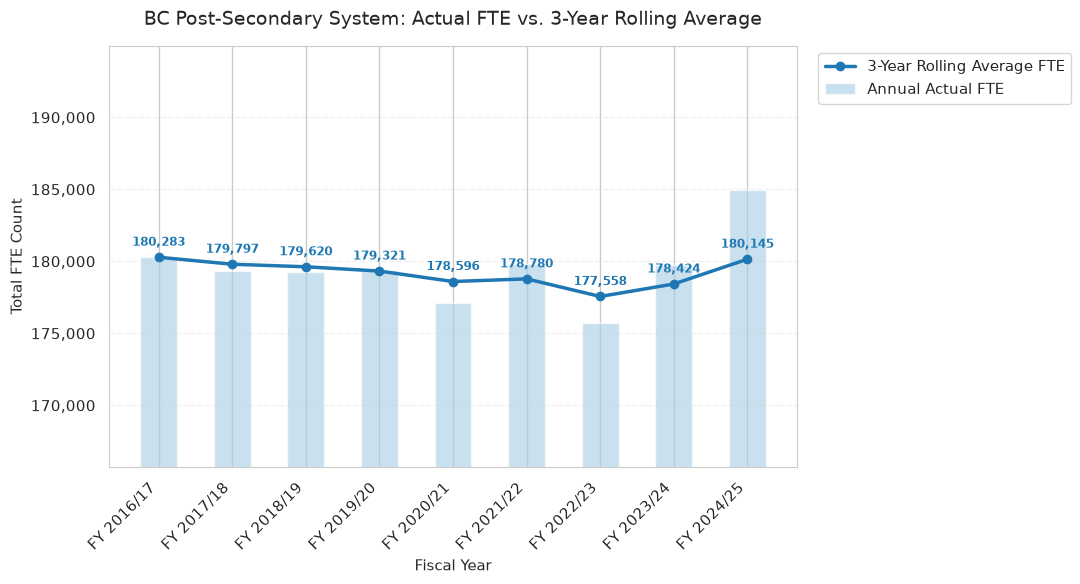

In [33]:
# ==============================================================================
# Query 3: Running 3-Year Rolling Average of FTE Enrolment
# ==============================================================================
query_system_rolling = """
WITH annual_system_fte AS (
    SELECT 
        fiscal_year,
        SUM(fte_actual) AS total_fte
    FROM fact_institution_financials_fte
    GROUP BY fiscal_year
)
SELECT 
    fiscal_year,
    total_fte,
    ROUND(
        AVG(total_fte) OVER (
            ORDER BY fiscal_year 
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2
    ) AS rolling_3yr_avg_fte
FROM annual_system_fte
ORDER BY fiscal_year;
"""

df_system_rolling = pd.read_sql(query_system_rolling, engine)

plt.figure(figsize=(11, 6))

# Annual Actual FTE Bars
plt.bar(
    df_system_rolling['fiscal_year'], 
    df_system_rolling['total_fte'], 
    color='#a6cee3', 
    alpha=0.6, 
    width=0.5,
    label='Annual Actual FTE'
)

# 3-Year Rolling Average Line
plt.plot(
    df_system_rolling['fiscal_year'], 
    df_system_rolling['rolling_3yr_avg_fte'], 
    color='#1f78b4', 
    marker='o', 
    linewidth=2.5, 
    label='3-Year Rolling Average FTE'
)

plt.title('BC Post-Secondary System: Actual FTE vs. 3-Year Rolling Average', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('Total FTE Count', fontsize=11)

plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter('{x:,.0f}')

# Adjust y-axis range to highlight variations (~160,000 to ~190,000)
min_fte = df_system_rolling['total_fte'].min()
max_fte = df_system_rolling['total_fte'].max()
plt.ylim(min_fte - 10000, max_fte + 10000)

# Add data callouts on points
for _, row in df_system_rolling.iterrows():
    plt.text(
        row['fiscal_year'], 
        row['rolling_3yr_avg_fte'] + 800, 
        f"{row['rolling_3yr_avg_fte']:,.0f}", 
        ha='center', 
        fontsize=8.5, 
        fontweight='bold',
        color='#1f78b4'
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/processed/03_fte_rolling_3yr_avg_system.png', dpi=300, bbox_inches='tight')
plt.show()

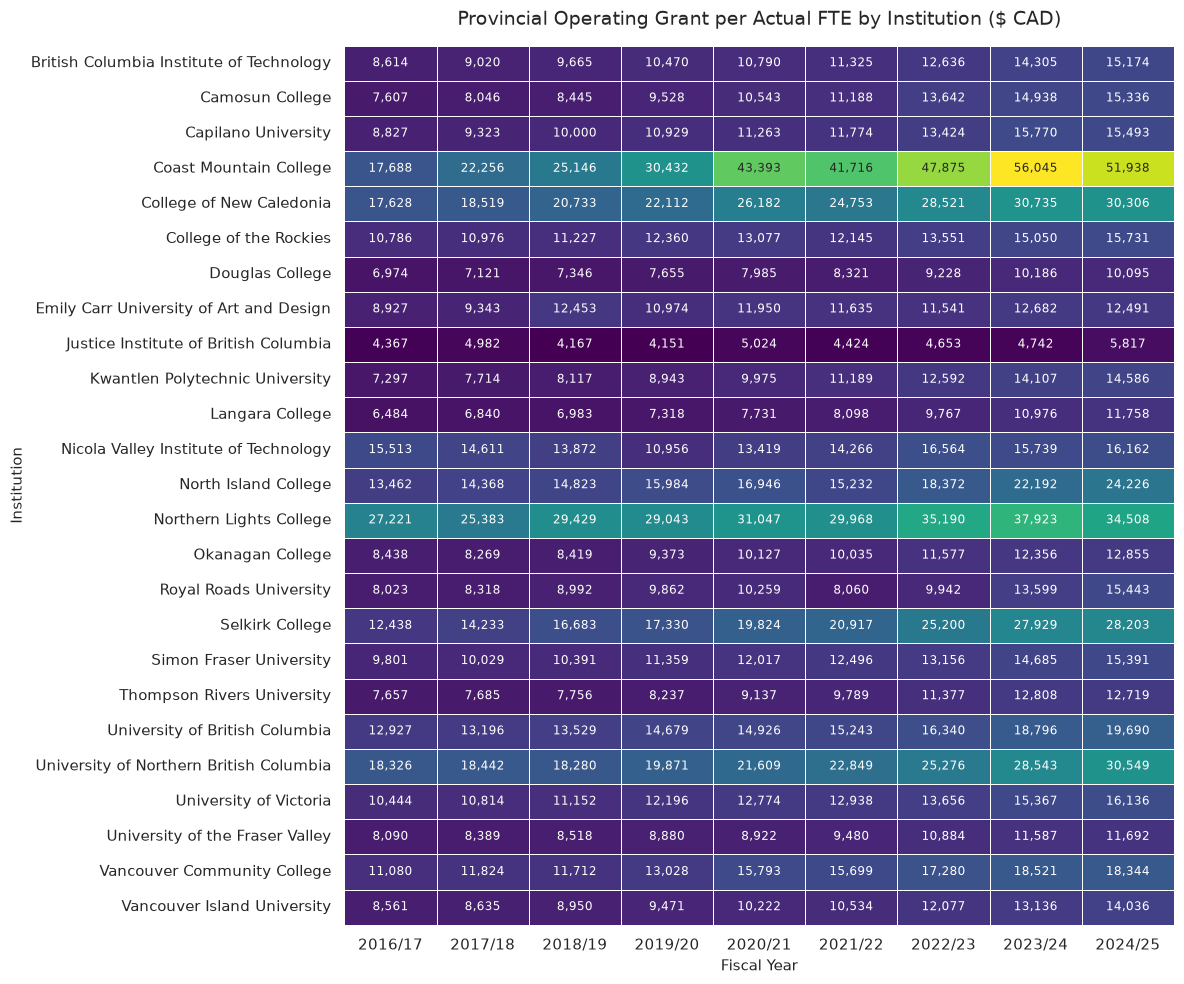

In [49]:
# ==============================================================================
# Query 4: Funding per FTE Trend
# ==============================================================================

query_grant_per_fte = """
WITH fte_totals AS (
    SELECT 
        institution_id,
        fiscal_year,
        SUM(fte_actual) AS total_fte
    FROM fact_institution_financials_fte
    GROUP BY institution_id, fiscal_year
),
grant_totals AS (
    SELECT 
        institution_id,
        fiscal_year,
        SUM(operating_grant) AS total_grant
    FROM fact_institution_financials_fte
    GROUP BY institution_id, fiscal_year
)
SELECT 
    i.institution_name,
    f.fiscal_year,
    g.total_grant AS operating_grant_cad,
    f.total_fte AS actual_fte,
    ROUND(g.total_grant / NULLIF(f.total_fte, 0), 2) AS grant_per_fte
FROM fte_totals f
JOIN grant_totals g 
    ON f.institution_id = g.institution_id 
   AND f.fiscal_year = g.fiscal_year
JOIN dim_institution i 
    ON f.institution_id = i.institution_id
ORDER BY i.institution_name, f.fiscal_year;
"""

df_grant = pd.read_sql(query_grant_per_fte, engine)

df_grant['fiscal_year'] = df_grant['fiscal_year'].astype(str).str.replace('FY ', '')

# Pivot for Heatmap (Institutions x Fiscal Years)
df_grant_pivot = df_grant.pivot(
    index='institution_name', 
    columns='fiscal_year', 
    values='grant_per_fte'
)

# Plot Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_grant_pivot,
    annot=True,
    fmt=",.0f",
    cmap="viridis",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8.5}
)

plt.title('Provincial Operating Grant per Actual FTE by Institution ($ CAD)', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('Institution', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/04_grant_per_fte_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

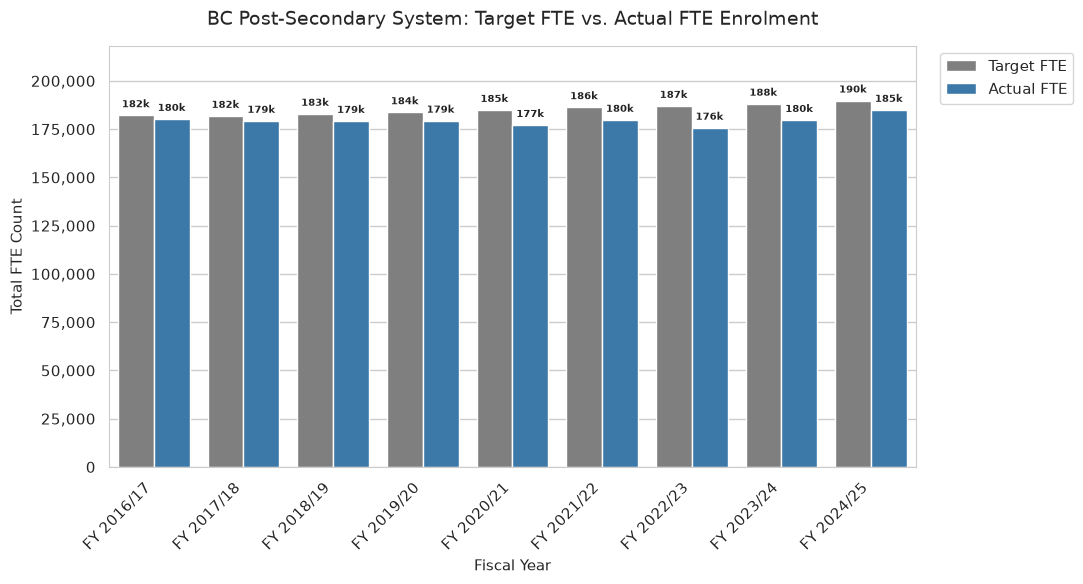

In [ ]:
# ==============================================================================
# Query 5: Actual FTE vs. Target FTE Variance
# ==============================================================================

query_fte_variance = """
SELECT 
    i.institution_name,
    f.fiscal_year,
    SUM(f.fte_target) AS target_fte,
    SUM(f.fte_actual) AS actual_fte,
    SUM(f.fte_actual) - SUM(f.fte_target) AS fte_variance,
    ROUND(
        (SUM(f.fte_actual) - SUM(f.fte_target)) / NULLIF(SUM(f.fte_target), 0) * 100, 2
    ) AS variance_pct
FROM fact_institution_financials_fte f
JOIN dim_institution i ON f.institution_id = i.institution_id
GROUP BY i.institution_name, f.fiscal_year
ORDER BY i.institution_name, f.fiscal_year;
"""

df_variance = pd.read_sql(query_fte_variance, engine)

# Aggregate Total System Target vs. Actual by Fiscal Year
df_system_fte = df_variance.groupby('fiscal_year').agg(
    target_fte=('target_fte', 'sum'),
    actual_fte=('actual_fte', 'sum')
).reset_index()

# Melt DataFrame for Seaborn Grouped Bar Plot
df_system_melted = df_system_fte.melt(
    id_vars=['fiscal_year'], 
    value_vars=['target_fte', 'actual_fte'], 
    var_name='metric', 
    value_name='fte_count'
)
df_system_melted['metric'] = df_system_melted['metric'].map({
    'target_fte': 'Target FTE', 
    'actual_fte': 'Actual FTE'
})

# Plot Grouped Bar Chart
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df_system_melted, 
    x='fiscal_year', 
    y='fte_count', 
    hue='metric', 
    palette={'Target FTE': '#7f7f7f', 'Actual FTE': '#2b7bba'}
)

# Add non-overlapping annotations above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height/1000:.0f}k',  # Renders as '182k' and '180k'
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=7.5, color='#222222', fontweight='bold'
        )

# Expand upper Y limit so annotations don't hit figure ceiling
ax.set_ylim(0, df_system_melted['fte_count'].max() * 1.15)
ax.yaxis.set_major_formatter('{x:,.0f}')

plt.title('BC Post-Secondary System: Target FTE vs. Actual FTE Enrolment', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('Total FTE Count', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Move legend outside right boundary
plt.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('../data/processed/05_fte_target_vs_actual_system.png', dpi=300, bbox_inches='tight')
plt.show()

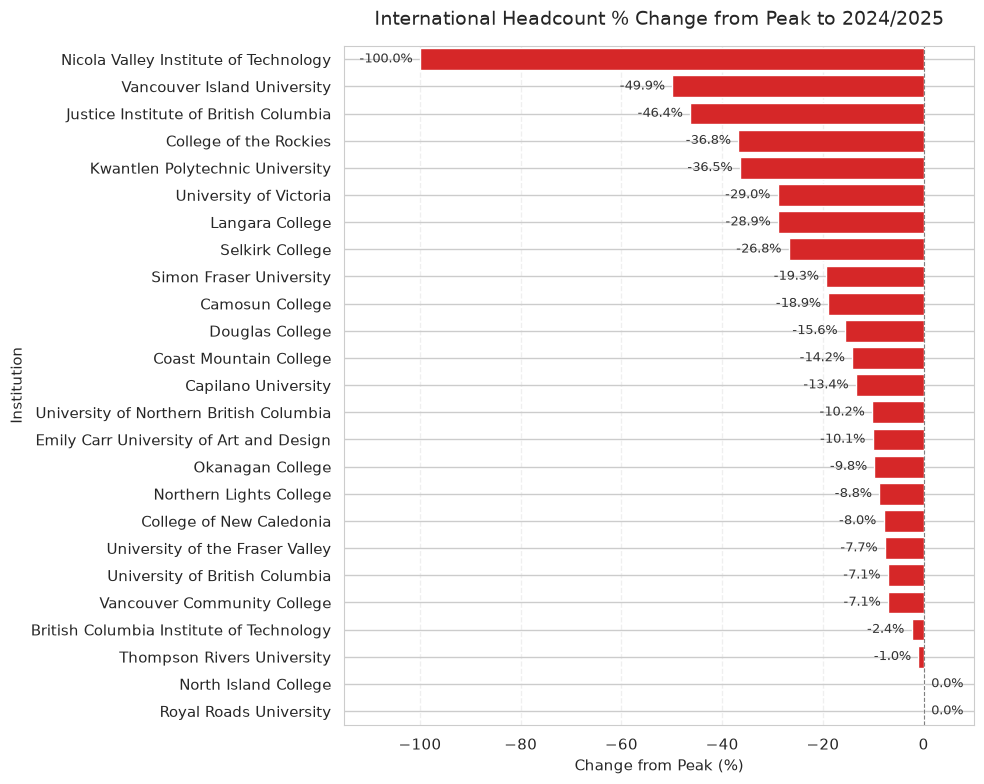

In [37]:
# ==============================================================================
# Query 6: Institutions with Steepest International Declines
# ==============================================================================

query_peak_drop = """
WITH intl_by_inst AS (
    SELECT 
        i.institution_name,
        f.fiscal_year,
        SUM(f.headcount) AS intl_headcount
    FROM fact_student_headcount f
    JOIN dim_institution i ON f.institution_id = i.institution_id
    WHERE f.student_type = 'International'
    GROUP BY i.institution_name, f.fiscal_year
),
inst_peak_vs_recent AS (
    SELECT 
        institution_name,
        MAX(intl_headcount) AS peak_intl_headcount,
        SUM(CASE WHEN fiscal_year = '2024/2025' THEN intl_headcount ELSE 0 END) AS recent_intl_headcount
    FROM intl_by_inst
    GROUP BY institution_name
)
SELECT 
    institution_name,
    peak_intl_headcount,
    recent_intl_headcount,
    recent_intl_headcount - peak_intl_headcount AS headcount_drop,
    ROUND(
        (CAST(recent_intl_headcount AS FLOAT) - peak_intl_headcount) / NULLIF(peak_intl_headcount, 0) * 100, 2
    ) AS pct_drop_from_peak
FROM inst_peak_vs_recent
WHERE peak_intl_headcount > 0
ORDER BY pct_drop_from_peak ASC;
"""

df_drop = pd.read_sql(query_peak_drop, engine)

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 8))

colors = ['#d62728' if x < 0 else '#1f77b4' for x in df_drop['pct_drop_from_peak']]
bars = plt.barh(df_drop['institution_name'], df_drop['pct_drop_from_peak'], color=colors)

plt.title('International Headcount % Change from Peak to 2024/2025', fontsize=14, pad=15)
plt.xlabel('Change from Peak (%)', fontsize=11)
plt.ylabel('Institution', fontsize=11)

# Eliminate categorical y-axis margin padding
plt.gca().margins(y=0)

# Crop exactly to the total count of unique institutions
plt.ylim(len(df_drop) - 0.5, -0.5)

# Set x-axis limit
plt.xlim(-115, 10)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Add text labels on the outside of each bar
for bar in bars:
    width = bar.get_width()
    if width < 0:
        plt.text(
            width - 1.5, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', 
            va='center', 
            ha='right',
            fontsize=9, 
            color='#333333'
        )
    else:
        plt.text(
            1.5, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', 
            va='center', 
            ha='left',
            fontsize=9, 
            color='#333333'
        )

plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/processed/06_intl_headcount_drop_from_peak.png', dpi=300, bbox_inches='tight')
plt.show()

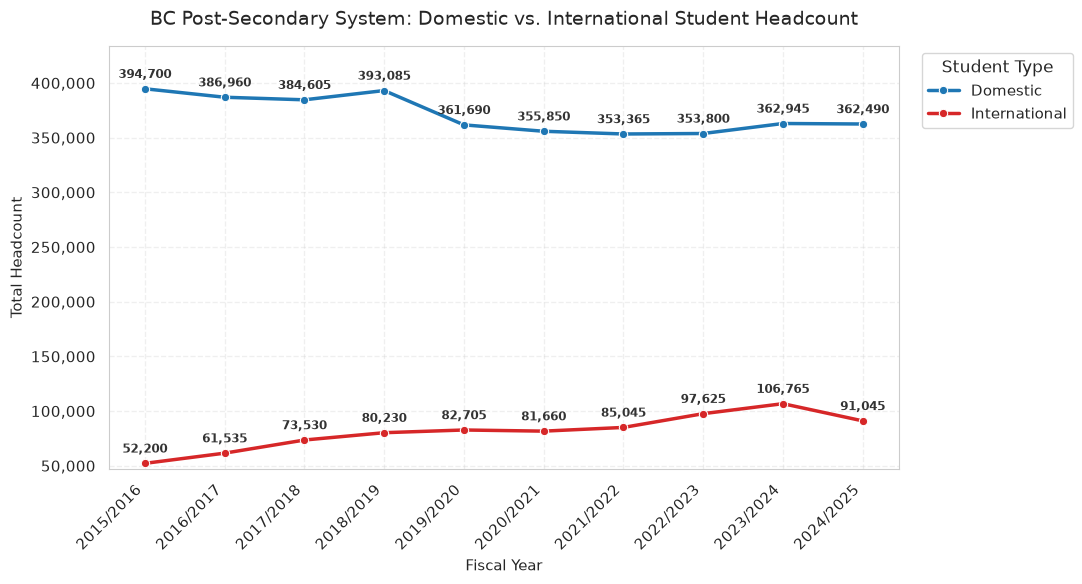

In [ ]:
# ==============================================================================
# Query 7: Domestic vs. International Student Headcount
# ==============================================================================
query_domestic_vs_intl = """
SELECT 
    fiscal_year,
    student_type,
    SUM(headcount) AS total_headcount
FROM fact_student_headcount
WHERE student_type IN ('Domestic', 'International')
GROUP BY fiscal_year, student_type
ORDER BY fiscal_year, student_type;
"""

df_type_trend = pd.read_sql(query_domestic_vs_intl, engine)

# Plot Grouped Trend Lines
plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=df_type_trend, 
    x='fiscal_year', 
    y='total_headcount', 
    hue='student_type', 
    marker='o', 
    linewidth=2.5,
    palette={'Domestic': '#1f77b4', 'International': '#d62728'}
)

plt.title('BC Post-Secondary System: Domestic vs. International Student Headcount', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=11)
plt.ylabel('Total Headcount', fontsize=11)

plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter('{x:,.0f}')

# Adjust y-axis range to give top padding
min_val = df_type_trend['total_headcount'].min()
max_val = df_type_trend['total_headcount'].max()
plt.ylim(min_val * 0.9, max_val * 1.1)

# Annotate points with formatted numbers
for _, row in df_type_trend.iterrows():
    plt.text(
        row['fiscal_year'], 
        row['total_headcount'] + (max_val * 0.025), 
        f"{row['total_headcount']:,.0f}", 
        ha='center', 
        fontsize=8.5,
        fontweight='bold',
        color='#333333'
    )

plt.legend(title='Student Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/07_domestic_vs_intl_headcount_trend.png', dpi=300, bbox_inches='tight')
plt.show()

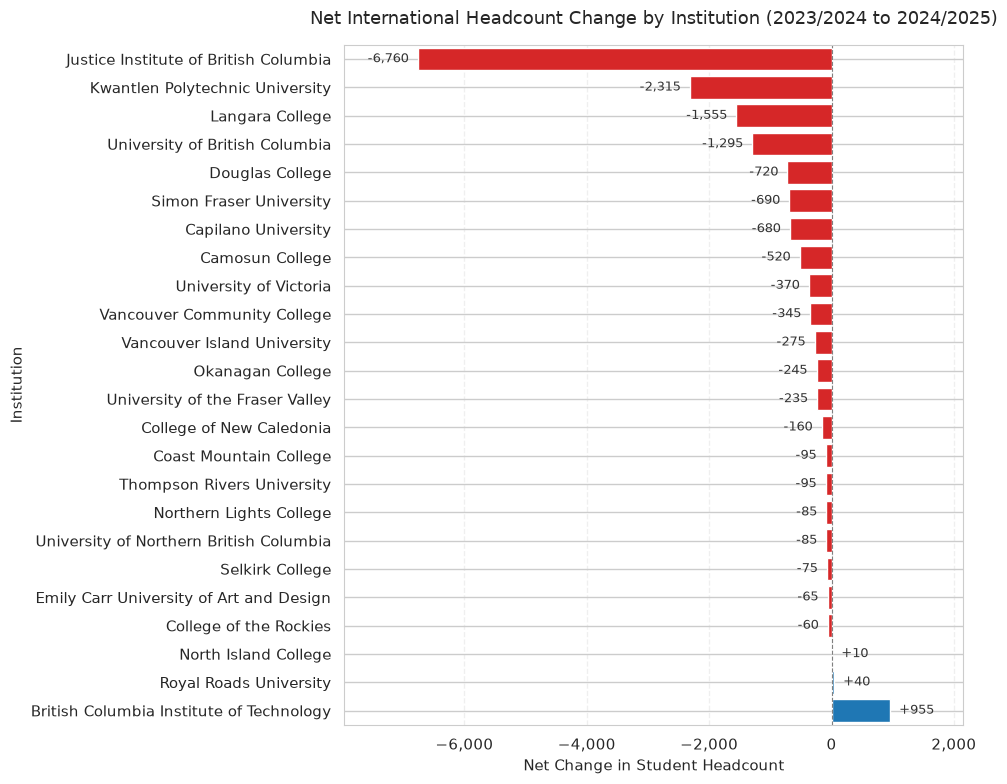

In [ ]:
# ==============================================================================
# Query 8: Headcount Change from 2023/2024 to 2024/2025
# ==============================================================================
query_net_change = """
WITH intl_by_inst AS (
    SELECT 
        i.institution_name,
        f.fiscal_year,
        SUM(f.headcount) AS intl_headcount
    FROM fact_student_headcount f
    JOIN dim_institution i ON f.institution_id = i.institution_id
    WHERE f.student_type = 'International'
      AND f.fiscal_year IN ('2023/2024', '2024/2025')
    GROUP BY i.institution_name, f.fiscal_year
)
SELECT 
    institution_name,
    SUM(CASE WHEN fiscal_year = '2023/2024' THEN intl_headcount ELSE 0 END) AS hc_2023_24,
    SUM(CASE WHEN fiscal_year = '2024/2025' THEN intl_headcount ELSE 0 END) AS hc_2024_25,
    SUM(CASE WHEN fiscal_year = '2024/2025' THEN intl_headcount ELSE 0 END) - 
    SUM(CASE WHEN fiscal_year = '2023/2024' THEN intl_headcount ELSE 0 END) AS net_change
FROM intl_by_inst
GROUP BY institution_name
ORDER BY net_change ASC;
"""

df_change = pd.read_sql(query_net_change, engine)

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 8))

colors = ['#d62728' if x < 0 else '#1f77b4' for x in df_change['net_change']]
bars = plt.barh(df_change['institution_name'], df_change['net_change'], color=colors)

plt.title('Net International Headcount Change by Institution (2023/2024 to 2024/2025)', fontsize=13, pad=15)
plt.xlabel('Net Change in Student Headcount', fontsize=11)
plt.ylabel('Institution', fontsize=11)

# Eliminate categorical y-axis margin padding
plt.gca().margins(y=0)
plt.ylim(len(df_change) - 0.5, -0.5)

# Set x-axis limit
min_val = df_change['net_change'].min()
max_val = df_change['net_change'].max()
plt.xlim(min_val - 1200, max_val + 1200)

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.gca().xaxis.set_major_formatter('{x:,.0f}')

# Add value labels next to bars
for bar in bars:
    width = bar.get_width()
    if width < 0:
        plt.text(
            width - 150, 
            bar.get_y() + bar.get_height()/2, 
            f'{width:,.0f}', 
            va='center', 
            ha='right',
            fontsize=9, 
            color='#333333'
        )
    elif width > 0:
        plt.text(
            width + 150, 
            bar.get_y() + bar.get_height()/2, 
            f'+{width:,.0f}', 
            va='center', 
            ha='left',
            fontsize=9, 
            color='#333333'
        )

plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/processed/8_intl_headcount_net_change_by_inst.png', dpi=300, bbox_inches='tight')
plt.show()